# Think In LangGraph
前两节我们学习了 LangGraph 的三要素和七种编排模式，它们解决的是 「怎么做」 的问题。

本节换个角度，从零构建一个客户支持 Agent 的完整流程，理解 LangGraph 背后的思维框架——「怎么想」。

LangGraph 构建 Agent 有5个核心阶段：
- 将任务拆解为一个个离散的节点，Node
- 明确每个节点的具体任务
- 设计节点中流转的数据格式，State
- 编写节点函数，做好异常处理
- 连接节点，形成图，Graph
传统 Prompt Chaining 是线性的 A→B→C，但真实世界的 Agent 是有分支、有回路、有人工介入的图结构。

要正确创建这个图就必须学会LangGraph的思维，接下来我们就一个客户支持的EmailAgent为例来学习如何Thinking in LangGraph.

客户支持 Agent：需求分析

假设我们要构建一个自动处理客服邮件的 Agent，它需要：
- 读取收件箱中的新邮件
- 按紧急程度和主题分类
- 搜索知识库文档寻找答案
- 撰写回复草稿
- 复杂问题升级给人工处理
- 必要时安排跟进

以下五个场景代表了不同类型的问题：
| 场景 | 类型 | 处理策略 |
| --- | --- | --- |
| 密码重置 | 简单问题 | 查文档 → 自动回复 |
| PDF导出崩溃 | Bug | 创建工单 → 人工审核 |
| 重复扣款 | 紧急账单 | 直接人工处理 |
| 暗黑模式功能 | 功能请求 | 查文档 → 标记feature |
| API间歇性504 | 复杂技术 | 直接人工处理 |

核心观察：不同的问题类型走不同的处理路径 —— 这就是我们需要图而不是链的原因。

## 1. 设计工作流
首先不着急写代码，先梳理业务，把业务流程用图画出来：
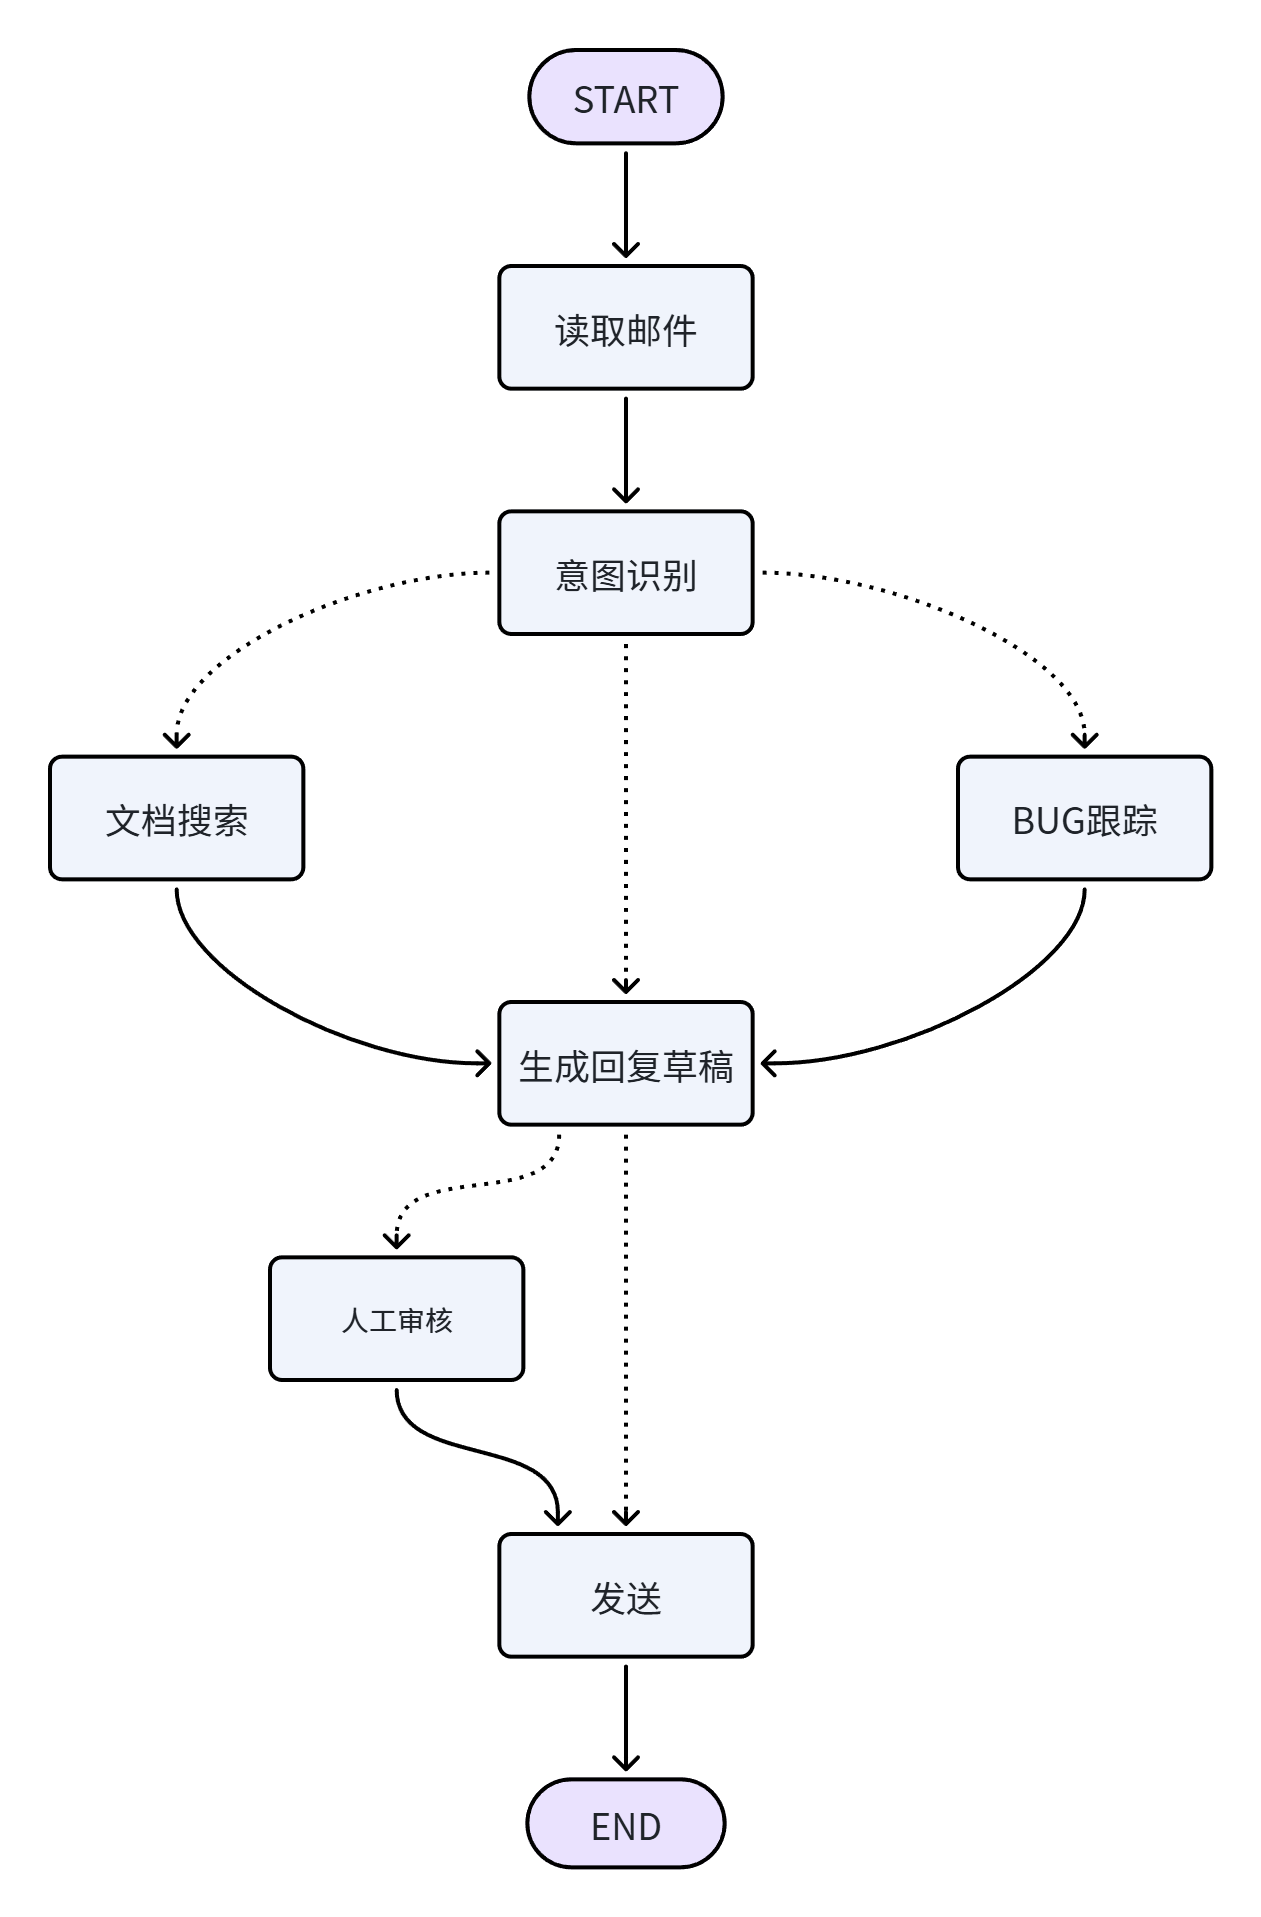
七个节点，虚线表示条件路径。不过，我们不定义条件边，而是把决策定义在节点内部。

每个节点只做一件事：
| 节点 | 职责 | 决策？ |
| --- | --- | --- |
| 读取邮件 | 解析邮件内容和发件人 | 否 |
| 意图识别 | LLM分类意图+紧急度，决定下一步路径 | 是 |
| 文档搜索 | 搜索知识库 | 否 |
| BUG跟踪 | 创建/更新 Bug 工单 | 否 |
| 生成草稿 | LLM生成回复草稿，判断是否需要人工审核 | 是 |
| 人工审核 | 暂停等待人工审批 | 否 |
| 发送 | 发送邮件 | 否 |

## 2. 理清节点的职责
接下来还不是写代码，而是先明确每个节点的输入、输出、失败策略。这决定了你的 State 设计和Node的错误处理架构。而这些跟节点的职责类型有关。

LangGraph 中有节点按照职责可以分为四类：
- LLM节点：主要职责是理解、分析、生成
- Data节点：主要职责是检索外部数据
- Action节点：职责是执行外部操作
- Human节点：职责是负责人机交互

接下来， 我们看看本例中的节点分别属于哪种，各自的输入和输出及失败策略。
### 2.1 LLM 节点
| 节点 | 静态上下文（Prompt模板） | 动态上下文（State） | 期望输出 |
| --- | --- | --- | --- |
| 意图识别 | 分类类别、紧急度定义 | 邮件内容、发件人 | 结构化分类结果 + 路由 |
| 生成草稿 | 语气指南、公司政策 | 分类结果、搜索结果、客户历史 | 专业回复草稿 |

### 2.2 Data 节点
| 节点 | 查询参数 | 重试策略 | 缓存 |
| --- | --- | --- | --- |
| 文档检索 | 从意图和主题构建查询 | 快速失败重试 | 常用查询永久缓存 |
| 客户信息查询 | 客户邮箱或ID | 重试+降级到基本信息 | 客户信息可设置TTL缓存 |

### 2.3 Action 节点
| 节点 | 执行时机 | 重试策略 | 幂等性 |
| --- | --- | --- | --- |
| 发送邮件 | 审批之后 | 网络问题快速失败重试 | 不缓存，每次唯一 |
| BUG跟踪 | 意图为bug时 | 必须重试，不能丢失BUG报告 | 返回Ticket ID |

### 2.4 Human 节点
| 节点 | 呈现给人工的上下文 | 预期输入 | 触发条件 |
| --- | --- | --- | --- |
| 人工确认 | 原邮件 + 草稿 + 紧急度 + 分类 | 是否批准或修改后的回复 | 高紧急度、复杂问题 |

## 3. 设计 State
State 是所有节点共享的"工作笔记本"。怎么判断一个字段要不要放 State？

原则：如果下游节点需要用它做决策或处理，就入 State。如果能从其他字段推导出来，就不存。

对于我们的Email Agent，我们需要存入State的信息包括：
- 原始邮件及发件人信息（之后无法重建）
- 分类结果（被后续多个节点所需）
- 搜索结果和客户数据（重新获取成本较高）
- 回复邮件的草稿（需在评审期间展示）

因此，其State要这样定义：

In [1]:
from typing import TypedDict, Literal

# 意图识别的结构化输出
class EmailClassification(TypedDict):
    intent: Literal["question", "bug", "billing", "feature", "complex"]
    urgency: Literal["low", "medium", "high", "critical"]
    topic: str
    summary: str

# 邮件State
class EmailAgentState(TypedDict):
    # 原始输入
    email_content: str
    sender_email: str
    email_id: str
    # 分类结果
    classification: EmailClassification | None
    # 外部数据
    search_results: list[str] | None
    customer_history: dict | None
    # 生成内容
    draft_response: str | None

## 4. 构建节点
分析好节点职责，接下来就是创建节点了。节点就是一个 Python 函数，接收当前 State，返回 State 更新。

不过，要特别注意的是工作流中的任何一个节点异常都可能导致整个工作流崩溃！所以，必须妥善处理节点中出现的异常。

不同的异常类型往往有不同的处理策略：
| 错误类型 | 谁来修复 | 处理策略 |
| --- | --- | --- |
| 短期异常 (网络问题、限流) | 系统自修复 | 多次重试：异常属于临时现象，多次重试就可能恢复正常 |
| LLM调用异常 (工具执行失败,数据格式问题) | LLM | 把错误信息写入State，再次交给LLM来处理 |
| 用户输入错误 (信息缺失、格式错误) | 用户 | 基于 interrupt()，人工修复 |
| 可恢复的错误 | 开发者 | 重试次数耗尽后，通过定义的error_handler来处理 |
| 其它预料之外的错误 | 开发者 | 直接抛出 |
接下来，我们分别定义各个节点：

### 4.1 邮件读取与意图识别
意图识别后需要判断分支走向：
- 简单问题：检索文档
- BUG报告：BUG跟踪
- 其它：人工审核（此处我们改一下，先去生成草稿，再人工审核，让人工在草稿基础上去改，省事）

这里我们不用条件边，而是用Command来指定下个节点。

In [ ]:
from langchain_classic.chains import llm
from typing import Literal
from langgraph.graph import StateGraph, START, END
from langgraph.types import Command, RetryPolicy

# 给LLM绑定结构化输出，做为路由决策
classifier_llm = llm.with_structured_output(EmailClassification)

def read_email(state: EmailAgentState) -> dict:
    """节点1: 解析邮件——总是走到下一个固定节点"""
    # 真实业务可以连接邮件服务器，读取信息
    print(f"  [Read] 收到邮件: {state['email_id']}")
    return {}

# 这里基于Command直接编写跳转规则，省去了conditional edge
def classify_intent(state: EmailAgentState)-> Command[Literal["search_documentation", "bug_tracking", "draft_response"]]:
    """节点2: LLM分类 + 路由决策"""
    # 先调用llm，做意图识别分类
    classification = classifier_llm.invoke(f"""
        分析这封客户邮件并分类：
        邮件: {state['email_content']}
        发件人: {state['sender_email']}
        提供 intent（question/bug/billing/feature/complex）、urgency、topic、summary。
    """)

    # 根据分类结果决定数据 下个Node
    if classification['intent'] in ['question', 'feature']:
        goto = "search_documentation"
    elif classification['intent'] == 'bug':
        goto = "bug_tracking"
    else:
        # billing、complex → 跳过数据收集，直接生成草稿（draft 会判断是否需要人工审核）
        goto = "draft_response"

    print(f"  [Classify] intent={classification['intent']}, urgency={classification['urgency']}")
    print(f"  [Classify] -> 路由到: {goto}")
    return Command(
        update={"classification": classification},
        goto=goto
    )

### 4.2 文档搜索与BUG跟踪
文档搜索和BUG跟踪都可以看做是具体的工作节点，完成后都需要跳转到生成草稿的节点。

In [ ]:
# 文档搜索/BUG工单处理完成后直接跳去draft_response，直接用Command跳转

def search_documentation(state: EmailAgentState) ->Command[Literal['draft_response']]:
    """节点3: 搜索知识库（带重试策略）"""
    classification = state.get('classification', {})
    query = f"{classification.get('intent', '')} {classification.get('topic', '')}"
    print(f"  [Search] 查询: {query}")

    # 模拟知识库搜索，实际开发可以改为RAG
    search_results = [
        "密码重置: 登录 -> 设置 -> 安全 -> 修改密码",
        "密码至少12位，包含大小写和特殊字符",
        "两步验证开启方法: 安全设置 -> 两步验证"
    ]
    return Command(
        update={"search_results": search_results},
        goto="draft_response"
    )

def bug_tracking(state: EmailAgentState) ->Command[Literal['draft_response']]:
    """节点4: 创建 Bug 工单"""
    ticket_id = f"BUG-{hash(state['email_id']) % 100000:05d}"
    print(f"  [BugTrack] 创建工单 {ticket_id}")

    return Command(
        update={
            "search_results": [f"Bug 工单 {ticket_id} 已创建"],
            "customer_history": {"ticket_id": ticket_id}
        },
        goto="draft_response"
    )

print("节点 3-4 定义完成")

### 4.3 生成草稿
生成草稿后同样需要判断分支走向：
- 如果是对于紧急任务、复杂任务、账单相关，都走人工审核
- 其它类型：直接发送

In [ ]:
def draft_response(state: EmailAgentState) -> Command[Literal["human_review", "send_reply"]]:
    """节点5: LLM生成回复草稿 + 判断是否需要人工审核"""
    classification = state.get('classification', {})

    # 格式化上下文（在节点内部格式化，不污染State）
    context_parts = []
    if state.get('search_results'):
        context_parts.append("文档:\n" + "\n".join(f"- {r}" for r in state['search_results']))
    if state.get('customer_history'):
        context_parts.append(f"工单: {state['customer_history']}")

    prompt = f"""起草一封回复邮件：
客户: {state['sender_email']}
原邮件: {state['email_content']}
意图: {classification.get('intent')} | 紧急度: {classification.get('urgency')}
{chr(10).join(context_parts)}

要求：专业、友好、有针对性地解决用户问题。不超过100字。落款统一写“黑马程序员”。"""

    response = llm.invoke(prompt)
    print(f"  [Draft] 回复已生成 ({len(response.content)} 字符)")

    # 判断是否需要人工审核，对于紧急任务、复杂任务、账单相关，都走人工审核
    needs_review = (
        classification.get('urgency') in ['high', 'critical'] or
        classification.get('intent') in ['complex', 'billing']
    )
    goto = "human_review" if needs_review else "send_reply"
    print(f"  [Draft] -> 路由到: {goto}")

    return Command(update={"draft_response": response.content}, goto=goto)

print("节点 5 定义完成")

### 4.4 人工确认
人工确认需要与前端约定好交互方式。这里我们返回的信息包括：
- 原始邮件信息：发件人、原邮件内容
- 邮件意图信息：意图、紧急情况
- 回复邮件草稿
- 可选的行动：用来提示用户接下来的操作，这里我们简化为两个操作
  - approve：批准，直接发送
  - edit：修改后发送，需要返回修改后的邮件内容

In [ ]:
from langgraph.types import interrupt  # interrupt 在 langgraph.types 中

def human_review(state: EmailAgentState):
    """节点6: 人工审核"""
    classification = state.get('classification', {})

    human_decision = interrupt({
        "email_id": state.get('email_id',''),
        "original_email": state.get('email_content',''),
        "draft_response": state.get('draft_response',''),
        "urgency": classification.get('urgency'),
        "intent": classification.get('intent'),
        "action": "请审阅并批准或编辑此回复,输入[approve 或 edit]"
    })

    # Now process the human's decision
    if human_decision.get("action") == 'edit':
        # edit，用户修改了邮件，需要更新State
        return {"draft_response": human_decision.get("edited_response")}
    else:
        # approve，没有修改邮件，直接发送
        return {}

def send_reply(state: EmailAgentState) -> dict:
    """节点7: 发送邮件回复"""
    draft = state.get('draft_response', '')
    print(f"  [Send] 发送回复邮件给{state['sender_email']}成功...\n\n{draft}")
    return {}

print("节点 6-7 定义完成")

## 5. 构建图（最小边原则）
由于节点内部已经通过 Command 声明了路由，图的边只需要定义固定跳转和起点/终点，结构非常简洁。

In [ ]:
from langgraph.checkpoint.memory import InMemorySaver

workflow = StateGraph(EmailAgentState)

# 添加所有节点
workflow.add_node("read_email", read_email)
workflow.add_node("classify_intent", classify_intent)
# 带重试策略的节点
workflow.add_node(
    "search_documentation",
    search_documentation,
    retry_policy=RetryPolicy(max_attempts=3, initial_interval=1.0)
)
workflow.add_node("bug_tracking", bug_tracking)
workflow.add_node("draft_response", draft_response)
workflow.add_node("human_review", human_review)
workflow.add_node("send_reply", send_reply)

# 定义最小边，大部分跳转都已通过Command实现，只用定义少量串行edge即可
workflow.add_edge(START, "read_email")
workflow.add_edge("read_email", "classify_intent")
workflow.add_edge("human_review", "send_reply")
workflow.add_edge("send_reply", END)

# compile 时需要 checkpointer（interrupt 需要持久化）
app = workflow.compile(checkpointer=InMemorySaver())

display_graph(app)

## 6. 测试
我们分别测试三种场景：
- 普通问题
- BUG跟踪
- 紧急问题

### 6.1 普通问题

In [ ]:
# 测试三个不同场景
config_base = {"configurable": {"thread_id": "test"}}

print("=== 场景1: 密码重置（查文档 → 自动回复）===\n")
config1 = {"configurable": {"thread_id": "t1"}}
r1 = app.invoke({
    "email_content": "Hi，我忘记登录密码了，如何重置？",
    "sender_email": "jack@example.com", "email_id": "email-001",
    "classification": None, "search_results": None,
    "customer_history": None, "draft_response": None
}, config1)

### 6.2 BUG报告

In [ ]:
print(f"\n=== 场景2: Bug报告（建工单 → 回复）===\n")
config2 = {"configurable": {"thread_id": "t2"}}
r2 = app.invoke({
    "email_content": "PDF导出功能每次都会崩溃，急需修复！",
    "sender_email": "jane@corp.com", "email_id": "email-002",
    "classification": None, "search_results": None,
    "customer_history": None, "draft_response": None, "messages": None
}, config2)

print(f"  回复: {r2['draft_response']}...")

## 6.3 紧急问题

In [ ]:

print(f"\n=== 场景3: 账单问题（直接升级人工审核）===\n")
config3 = {"configurable": {"thread_id": "t3"}}
r3 = app.invoke({
    "email_content": "我被重复扣款了！这是什么情况！请立刻处理！",
    "sender_email": "jack@corp.com", "email_id": "vip-email-003",
    "classification": None, "search_results": None,
    "customer_history": None, "draft_response": None, "messages": None
}, config3)

没有打印出最终回复的邮件，这是因为需要人工审核。

我们模拟一个人工审核，比如approve：

In [ ]:
# 人工确认，比如approve
r4 = app.invoke(
    Command(resume={
        "action": "edit",
        "edited_response": """
    尊敬的VIP客户jack，

    非常抱歉给您带来不便！我们已紧急核查您的账户，确认存在重复扣款。我们将立即为您办理退款，预计1小时内原路返回。如有其他问题，请随时联系我们。再次感谢您的耐心！

    黑马程序员
        """
    }),
    config3
)